# 01_eda: ARnatomy (Anatomy AR Learning)
Tim Sukses Lancar ProjekNYA: Muhammad Akyas Febryansah (V3925029), Nehan Raki Alfawzi (V3925013)

Fokus Hari 1: komponen **RAG Asisten AI**. Dataset = knowledge base materi anatomi yang dipakai aplikasi (`src/lib/data.ts`: deskripsi organ, fakta, konten label dasar/dimmed, dan basis pengetahuan asisten), diekspor jadi `data/raw/knowledge_base_arnatomy.csv`. Evaluation set = 35 pertanyaan gaya siswa SMP-SMA beserta chunk jawaban yang benar.

## Soal 2a. Ukuran data, tipe kolom, statistik deskriptif

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
pd.set_option('display.max_colwidth', 80)

kb = pd.read_csv('../data/raw/knowledge_base_arnatomy.csv')
ev = pd.read_csv('../data/raw/eval_set_arnatomy.csv')
print('Ukuran knowledge base:', kb.shape)
print('Ukuran evaluation set:', ev.shape)
kb.info()

Ukuran knowledge base: (84, 10)
Ukuran evaluation set: (35, 4)
<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_chunk         84 non-null     str    
 1   sumber           84 non-null     str    
 2   id_organ         84 non-null     int64  
 3   id_bagian        80 non-null     float64
 4   nama_bagian      84 non-null     str    
 5   jenis_konten     84 non-null     str    
 6   aspek            84 non-null     str    
 7   status_validasi  84 non-null     str    
 8   judul            84 non-null     str    
 9   teks             84 non-null     str    
dtypes: float64(1), int64(1), str(8)
memory usage: 6.7 KB


In [2]:
kb['panjang_kata'] = kb['teks'].str.split().str.len()
kb['panjang_karakter'] = kb['teks'].str.len()
kb[['panjang_kata', 'panjang_karakter']].describe().round(2)

,panjang_kata,panjang_karakter
count,84.00,84.00
mean,17.77,121.49
std,8.79,60.24
min,8.00,50.00
25%,12.00,81.75
50%,14.00,95.00
75%,24.25,165.50
max,41.00,302.00


In [3]:
kb.head()

,id_chunk,sumber,id_organ,id_bagian,nama_bagian,jenis_konten,aspek,status_validasi,judul,teks,panjang_kata,panjang_karakter
0,C01,deskripsi_organ,1,NaN,Jantung,dasar,deskripsi,tervalidasi,Jantung,"Organ berotot seukuran kepalan tangan yang memompa darah ke seluruh tubuh, m...",26,171
1,C02,fakta_organ,1,NaN,Jantung,fakta,fakta,tervalidasi,Fakta Jantung,Ukuran: Sebesar kepalan tangan pemiliknya; Berat: 250 sampai 350 gram; Denyu...,37,234
2,C03,deskripsi_organ,2,NaN,Paru-paru,dasar,deskripsi,tervalidasi,Paru-paru,Sepasang organ berongga di rongga dada tempat udara yang dihirup bertukar ga...,24,169
3,C04,fakta_organ,2,NaN,Paru-paru,fakta,fakta,tervalidasi,Fakta Paru-paru,"Berat: Sekitar 1,1 kg untuk sepasang; Kapasitas: Sekitar 6 liter udara; Frek...",39,237
4,C05,fakta_bagian,1,1.0,Atrium Kanan,fakta,fakta,tervalidasi,Fakta Atrium Kanan,Tebal dinding: Sekitar 2 mm; Menerima dari: Vena cava superior dan inferior;...,16,105


## Soal 2b. Missing value, duplikat, dan variasi penulisan

In [4]:
print('Missing value per kolom:')
print(kb.isnull().sum())
print('\nBaris duplikat penuh      :', kb.duplicated().sum())
print('Teks chunk duplikat (persis):', kb['teks'].str.lower().str.strip().duplicated().sum())
print('\nNilai kategori:')
for kol in ['sumber', 'jenis_konten', 'aspek', 'status_validasi']:
    print(f'  {kol}: {kb[kol].unique().tolist()}')

Missing value per kolom:
id_chunk            0
sumber              0
id_organ            0
id_bagian           4
nama_bagian         0
jenis_konten        0
aspek               0
status_validasi     0
judul               0
teks                0
panjang_kata        0
panjang_karakter    0
dtype: int64

Baris duplikat penuh      : 0
Teks chunk duplikat (persis): 0

Nilai kategori:
  sumber: ['deskripsi_organ', 'fakta_organ', 'fakta_bagian', 'konten_label', 'pengetahuan_asisten']
  jenis_konten: ['dasar', 'fakta', 'dimmed', 'asisten']
  aspek: ['deskripsi', 'fakta', 'penjelasan', 'fungsi', 'letak', 'gangguan', 'ringkas']
  status_validasi: ['tervalidasi', 'draft']


In [5]:
# Variasi penulisan di dalam teks yang perlu dinormalisasi
pola = {'simbol ±': '±', 'strip rentang (–)': '–', 'strip panjang (—)': '—',
        'singkatan O2/CO2': r'\bC?O2\b', 'tanda kutip': '"',
        'paru (tanpa -paru)': r'\bparu\b(?!-)'}
for nama, p in pola.items():
    n = kb['teks'].str.contains(p, regex=True).sum()
    print(f'{nama:<22}: {n} chunk')

# Chunk yang tidak menyebut nama bagiannya sendiri (kehilangan konteks)
tanpa_nama = kb[~kb.apply(lambda r: r['nama_bagian'].lower().split()[0] in r['teks'].lower(), axis=1)]
print(f'\nChunk tanpa nama bagian di teksnya: {len(tanpa_nama)} dari {len(kb)}')
print(tanpa_nama[['id_chunk', 'nama_bagian', 'aspek', 'teks']].head(6).to_string())

simbol ±              : 3 chunk
strip rentang (–)     : 5 chunk
strip panjang (—)     : 1 chunk
singkatan O2/CO2      : 1 chunk
tanda kutip           : 3 chunk
paru (tanpa -paru)    : 29 chunk

Chunk tanpa nama bagian di teksnya: 36 dari 84
  id_chunk   nama_bagian      aspek                                                                                                                                                                                                                                           teks
0      C01       Jantung  deskripsi                                                                    Organ berotot seukuran kepalan tangan yang memompa darah ke seluruh tubuh, mengantar oksigen dan zat gizi ke setiap sel, lalu membawa pulang karbon dioksida untuk dibuang.
1      C02       Jantung      fakta     Ukuran: Sebesar kepalan tangan pemiliknya; Berat: 250 sampai 350 gram; Denyut: Sekitar 100.000 kali per hari; Letak: Di belakang tulang dada, condong ke kiri; Suplai dar

In [6]:
# Hampir-duplikat: pasangan chunk dengan kemiripan TF-IDF tinggi
tf = TfidfVectorizer().fit_transform(kb['teks'])
sim = cosine_similarity(tf)
np.fill_diagonal(sim, 0)
i, j = np.where(np.triu(sim) > 0.5)
pasangan = pd.DataFrame({'chunk_a': kb['id_chunk'].values[i], 'chunk_b': kb['id_chunk'].values[j],
                         'bagian': kb['nama_bagian'].values[i], 'cosine': sim[i, j].round(2)})
print('Pasangan hampir-duplikat (cosine > 0,5):', len(pasangan))
print(pasangan.sort_values('cosine', ascending=False).head(8).to_string(index=False))

Pasangan hampir-duplikat (cosine > 0,5): 6
chunk_a chunk_b          bagian  cosine
    C49     C53  Ventrikel Kiri    0.65
    C07     C08 Ventrikel Kanan    0.64
    C21     C45 Ventrikel Kanan    0.60
    C05     C17    Atrium Kanan    0.59
    C31     C72 Paru-paru Kanan    0.54
    C12     C29   Bronkus Utama    0.52


## Soal 2c. Distribusi "label" (sistem organ, bagian, status validasi)
Project RAG tidak punya label kelas, jadi yang dicek keseimbangannya adalah sebaran chunk per sistem organ dan per bagian, serta sebaran pertanyaan evaluasi.

In [7]:
kb['sistem_organ'] = kb['id_organ'].map({1: 'Sistem Peredaran Darah', 2: 'Sistem Pernapasan'})
print(kb['sistem_organ'].value_counts(), '\n')
print(kb['nama_bagian'].value_counts(), '\n')
print(kb['status_validasi'].value_counts(), '\n')
print('Pertanyaan evaluasi per sistem organ:')
print(ev['sistem_organ'].value_counts())

sistem_organ
Sistem Peredaran Darah    42
Sistem Pernapasan         42
Name: count, dtype: int64 

nama_bagian
Atrium Kanan              7
Atrium Kiri               7
Ventrikel Kiri            7
Aorta                     7
Trakea                    7
Bronkus Utama             7
Paru-paru Kanan           7
Alveolus                  7
Ventrikel Kanan           6
Katup Mitral              6
Paru-paru Kiri            6
Lobus Bawah Paru Kanan    6
Jantung                   2
Paru-paru                 2
Name: count, dtype: int64 

status_validasi
tervalidasi    81
draft           3
Name: count, dtype: int64 

Pertanyaan evaluasi per sistem organ:
sistem_organ
Sistem Pernapasan         18
Sistem Peredaran Darah    17
Name: count, dtype: int64


## Soal 2d. Grafik EDA

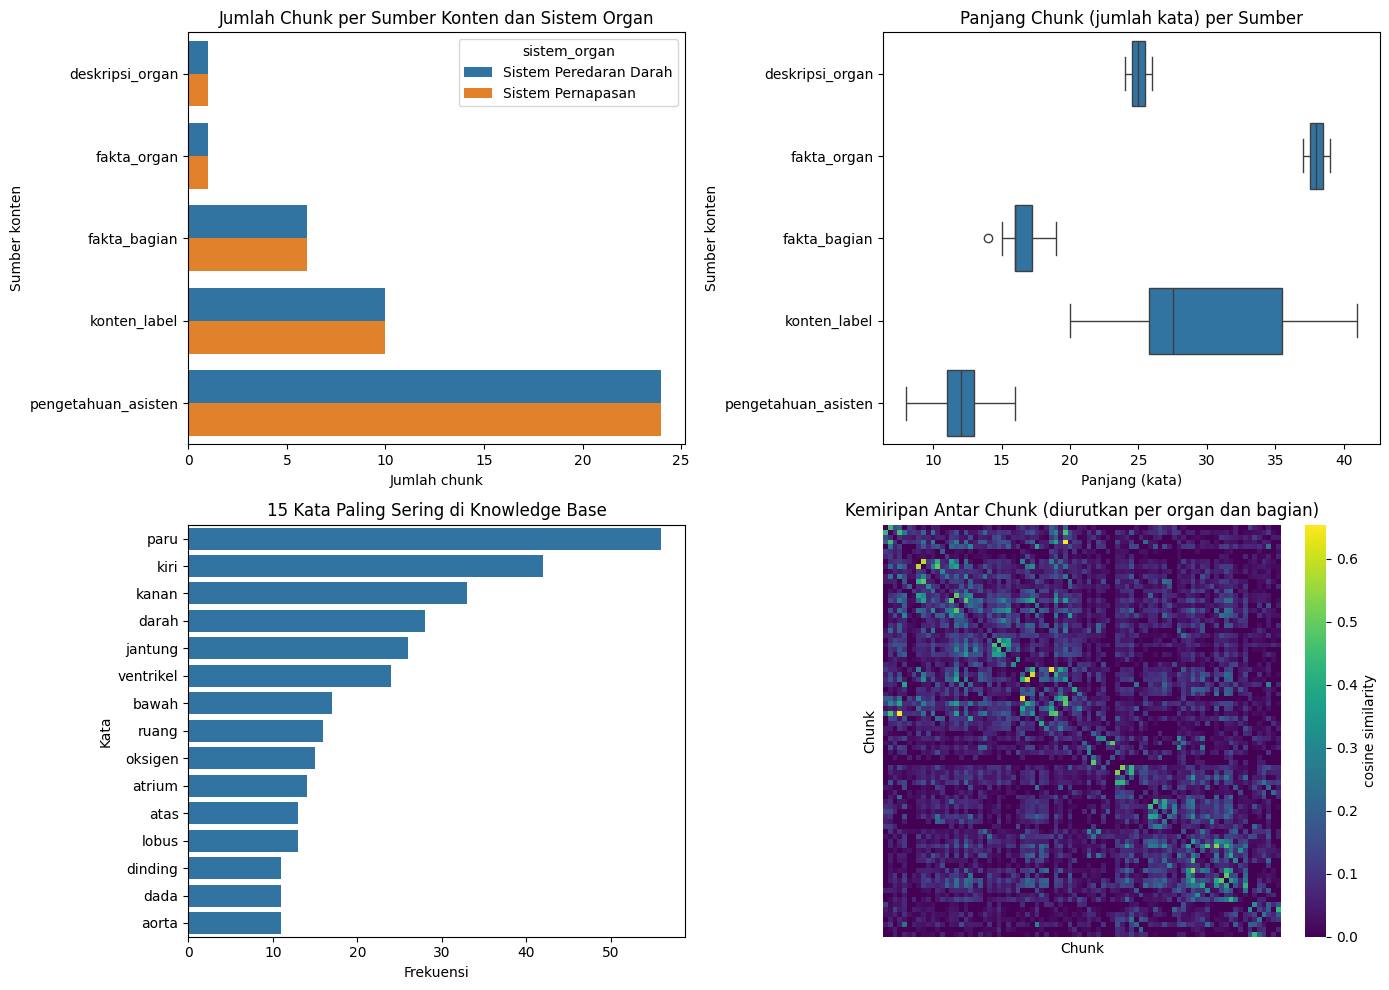

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=kb, y='sumber', hue='sistem_organ', ax=ax[0, 0])
ax[0, 0].set_title('Jumlah Chunk per Sumber Konten dan Sistem Organ')
ax[0, 0].set_xlabel('Jumlah chunk'); ax[0, 0].set_ylabel('Sumber konten')

sns.boxplot(data=kb, x='panjang_kata', y='sumber', ax=ax[0, 1])
ax[0, 1].set_title('Panjang Chunk (jumlah kata) per Sumber')
ax[0, 1].set_xlabel('Panjang (kata)'); ax[0, 1].set_ylabel('Sumber konten')

stop_id = ['yang', 'dan', 'di', 'ke', 'dari', 'dengan', 'untuk', 'karena', 'lalu',
           'saat', 'ini', 'itu', 'sampai', 'lebih', 'sekitar', 'atau', 'pada', 'seperti']
cv = TfidfVectorizer(stop_words=stop_id, use_idf=False, norm=None).fit(kb['teks'])
frek = pd.Series(np.asarray(cv.transform(kb['teks']).sum(axis=0)).ravel(),
                 index=cv.get_feature_names_out()).sort_values(ascending=False).head(15)
sns.barplot(x=frek.values, y=frek.index, ax=ax[1, 0])
ax[1, 0].set_title('15 Kata Paling Sering di Knowledge Base')
ax[1, 0].set_xlabel('Frekuensi'); ax[1, 0].set_ylabel('Kata')

urut = kb.sort_values(['id_organ', 'nama_bagian']).index
sns.heatmap(sim[np.ix_(urut, urut)], cmap='viridis', ax=ax[1, 1],
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'cosine similarity'})
ax[1, 1].set_title('Kemiripan Antar Chunk (diurutkan per organ dan bagian)')
ax[1, 1].set_xlabel('Chunk'); ax[1, 1].set_ylabel('Chunk')

plt.tight_layout()
plt.show()

### Insight EDA
1. **Data seimbang antar sistem organ**: 42 chunk peredaran darah dan 42 chunk pernapasan, tiap bagian punya 6 sampai 7 chunk, dan pertanyaan evaluasi 17 vs 18. Dampaknya, tidak ada organ yang "dianakemaskan" oleh retriever, dan Recall@k bisa dibandingkan per sistem organ secara adil.
2. **Panjang chunk sangat timpang dan banyak chunk kehilangan konteks**: chunk pengetahuan asisten rata-rata cuma sekitar 12 kata, sedangkan fakta organ sekitar 38 kata. Selain itu 36 dari 84 chunk tidak menyebut nama bagiannya sendiri (contoh: "Letaknya di bagian kanan atas jantung..."). Dampaknya, pertanyaan "atrium kanan letaknya di mana?" sulit menemukan chunk itu, sehingga perlu ditambahkan header konteks (nama bagian + aspek) di depan setiap chunk.
3. **Kata paling sering justru "paru", "kiri", "kanan", "bawah"**: kata penentu arah muncul di banyak chunk sehingga bobot IDF-nya rendah. Dampaknya, retriever rawan tertukar antara atrium kanan vs kiri atau paru kanan vs kiri, jadi header nama bagian penting untuk membedakan.
4. **Ada redundansi antar sumber**: heatmap menunjukkan blok kemiripan di dalam bagian yang sama dan ada 6 pasangan hampir-duplikat (misal fakta ventrikel kanan vs penjelasan ventrikel kanan). Dampaknya, satu pertanyaan bisa punya lebih dari satu chunk benar, sehingga evaluation set disusun dengan beberapa chunk kunci per pertanyaan.
5. **Ada 3 chunk berstatus draft** (belum divalidasi). Chunk ini harus dikeluarkan dari knowledge base supaya asisten tidak menjawab dengan materi yang belum dicek guru/admin.

## Soal 3. Pembersihan Data dan Feature Engineering (tipe e: dokumen untuk RAG)

In [9]:
kb_sebelum = kb.copy()
kb_bersih = kb.copy()

# 1) Buang konten berstatus draft: belum divalidasi guru/admin, tidak boleh jadi sumber jawaban
kb_bersih = kb_bersih[kb_bersih['status_validasi'] == 'tervalidasi'].copy()

# 2) Normalisasi teks: huruf kecil, simbol dan singkatan jadi kata baku
def normalisasi(t):
    t = t.lower()
    t = t.replace('co2', 'karbon dioksida').replace('o2', 'oksigen')
    t = t.replace('±', 'sekitar ').replace('–', ' sampai ').replace('—', ' ')
    t = t.replace('"', '').replace('(', ' ').replace(')', ' ').replace(';', '.')
    t = ' '.join(t.split())
    return t.replace(' ,', ',').replace(' .', '.')
kb_bersih['teks_bersih'] = kb_bersih['teks'].apply(normalisasi)

# 3) Buang duplikat persis setelah normalisasi
kb_bersih = kb_bersih.drop_duplicates(subset='teks_bersih')

# 4) Fitur turunan
kb_bersih['sistem_organ'] = kb_bersih['id_organ'].map({1: 'Sistem Peredaran Darah', 2: 'Sistem Pernapasan'})
kb_bersih['level'] = np.where(kb_bersih['jenis_konten'] == 'dimmed', 'lanjutan', 'dasar')
kb_bersih['panjang_kata'] = kb_bersih['teks_bersih'].str.split().str.len()
kb_bersih['ada_angka'] = kb_bersih['teks_bersih'].str.contains(r'\d').astype(int)

# 5) Header konteks: nama bagian dan aspek ditempel ke depan teks chunk
kb_bersih['teks_kb'] = (kb_bersih['nama_bagian'].str.lower() + ' (' + kb_bersih['aspek'] + '). '
                        + kb_bersih['teks_bersih'])

print('Ukuran sebelum:', kb_sebelum.shape, '| sesudah:', kb_bersih.shape)
print('Chunk draft yang dibuang:', (kb_sebelum['status_validasi'] == 'draft').sum())
print('\nContoh SEBELUM vs SESUDAH:')
for cid in ['C18', 'C16', 'C38']:
    print(f'[{cid}] sebelum: {kb_sebelum.loc[kb_sebelum.id_chunk == cid, "teks"].iloc[0]}')
    print(f'      sesudah: {kb_bersih.loc[kb_bersih.id_chunk == cid, "teks_kb"].iloc[0]}\n')

Ukuran sebelum: (84, 13) | sesudah: (81, 17)
Chunk draft yang dibuang: 3

Contoh SEBELUM vs SESUDAH:
[C18] sebelum: Dinding atrium kanan hanya setebal ± 2 mm karena cukup mendorong darah sejauh satu ruang. Di dindingnya terdapat nodus sinoatrial (SA node), pemacu alami jantung yang memicu 60–100 denyut per menit tanpa perintah dari otak.
      sesudah: atrium kanan (penjelasan). dinding atrium kanan hanya setebal sekitar 2 mm karena cukup mendorong darah sejauh satu ruang. di dindingnya terdapat nodus sinoatrial sa node, pemacu alami jantung yang memicu 60 sampai 100 denyut per menit tanpa perintah dari otak.

[C16] sebelum: Jumlah: 300 sampai 500 juta; Tebal dinding: Setebal satu sel; Fungsi: Tempat pertukaran O2 dan CO2
      sesudah: alveolus (fakta). jumlah: 300 sampai 500 juta. tebal dinding: setebal satu sel. fungsi: tempat pertukaran oksigen dan karbon dioksida

[C38] sebelum: Letaknya di bagian kanan atas jantung, persis di ujung masuknya vena cava superior dan inferior.
      

In [10]:
print('Jumlah chunk per sistem organ dan level:')
print(pd.crosstab(kb_bersih['sistem_organ'], kb_bersih['level']))
print('\nPanjang chunk (kata) setelah header:')
print(kb_bersih['teks_kb'].str.split().str.len().describe().round(2))
kb_bersih[['id_chunk', 'sistem_organ', 'nama_bagian', 'aspek', 'level',
           'panjang_kata', 'ada_angka', 'teks_kb']].head(8)

Jumlah chunk per sistem organ dan level:
level                   dasar  lanjutan
sistem_organ                           
Sistem Peredaran Darah     37         3
Sistem Pernapasan          38         3

Panjang chunk (kata) setelah header:
count    81.00
mean     20.23
std       8.59
min      10.00
25%      14.00
50%      16.00
75%      23.00
max      43.00
Name: teks_kb, dtype: float64


,id_chunk,sistem_organ,nama_bagian,aspek,level,panjang_kata,ada_angka,teks_kb
0,C01,Sistem Peredaran Darah,Jantung,deskripsi,dasar,26,0,jantung (deskripsi). organ berotot seukuran kepalan tangan yang memompa dara...
1,C02,Sistem Peredaran Darah,Jantung,fakta,dasar,37,1,jantung (fakta). ukuran: sebesar kepalan tangan pemiliknya. berat: 250 sampa...
2,C03,Sistem Pernapasan,Paru-paru,deskripsi,dasar,24,0,paru-paru (deskripsi). sepasang organ berongga di rongga dada tempat udara y...
3,C04,Sistem Pernapasan,Paru-paru,fakta,dasar,39,1,"paru-paru (fakta). berat: sekitar 1,1 kg untuk sepasang. kapasitas: sekitar ..."
4,C05,Sistem Peredaran Darah,Atrium Kanan,fakta,dasar,16,1,atrium kanan (fakta). tebal dinding: sekitar 2 mm. menerima dari: vena cava ...
5,C06,Sistem Peredaran Darah,Atrium Kiri,fakta,dasar,14,0,atrium kiri (fakta). menerima dari: empat vena pulmonalis. mengalir ke: vent...
6,C07,Sistem Peredaran Darah,Ventrikel Kanan,fakta,dasar,16,1,ventrikel kanan (fakta). tebal dinding: 3 sampai 5 mm. memompa ke: paru-paru...
7,C08,Sistem Peredaran Darah,Ventrikel Kiri,fakta,dasar,16,1,ventrikel kiri (fakta). tebal dinding: 8 sampai 15 mm. memompa ke: seluruh t...


In [11]:
import os
os.makedirs('../data/processed', exist_ok=True)
kolom = ['id_chunk', 'sistem_organ', 'nama_bagian', 'sumber', 'aspek', 'level',
         'panjang_kata', 'ada_angka', 'teks_bersih', 'teks_kb']
kb_bersih[kolom].to_csv('../data/processed/knowledge_base_bersih.csv', index=False)
ev.to_csv('../data/processed/eval_set.csv', index=False)
print('Tersimpan:', len(kb_bersih), 'chunk dan', len(ev), 'pertanyaan evaluasi.')

Tersimpan: 81 chunk dan 35 pertanyaan evaluasi.
